# 🚗 Detección y Lectura de Placas Vehiculares con YOLO11 y OCR

**Adaptación realizada por:** Alfredo Díaz  
**Dataset:** [Roboflow - placa-de-carro-sxy3a](https://roboflow.com)

---

## 📋 ¿Qué aprenderemos en este cuaderno?

En este notebook aprenderemos a construir un sistema completo de **detección y lectura automática de placas vehiculares** colombianas, usando:

| Herramienta | Función |
|---|---|
| **Roboflow** | Gestión y descarga del dataset etiquetado |
| **YOLO11** | Detección de la placa en la imagen |
| **OpenCV** | Procesamiento y recorte de la región de la placa |
| **EasyOCR** | Lectura de caracteres y ciudad de la placa |

## 🔄 Flujo del sistema

```
Imagen → YOLO11 detecta la placa → OpenCV recorta la región
       → EasyOCR lee caracteres → Extrae número + ciudad
```

## ⚙️ Requisitos
- Google Colab con GPU habilitada (Runtime → Change runtime type → T4 GPU)
- Cuenta en [Roboflow](https://roboflow.com) (gratuita)

---
## 📦 Paso 1: Instalación de Dependencias

Instalamos todas las librerías necesarias para el proyecto:

- **`ultralytics`**: Framework de YOLO11 para detección de objetos
- **`roboflow`**: SDK para descargar el dataset desde Roboflow
- **`easyocr`**: Motor OCR para leer texto en imágenes (soporta español e inglés)
- **`opencv-python`**: Librería de visión computacional para procesar imágenes
- **`split-folders`**: Utilidad para dividir datasets en train/val/test

In [ ]:
# Solo instalamos lo que NO viene en Google Colab
!pip install ultralytics roboflow easyocr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 106.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 138.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 37.6 MB/s eta 0:00:00


---
## 📚 Paso 2: Importación de Librerías

Importamos las librerías que usaremos a lo largo del notebook. Cada una tiene un rol específico:

- **`numpy` y `pandas`**: Manipulación de datos numéricos y tablas
- **`matplotlib`**: Visualización de gráficas y métricas de entrenamiento
- **`PIL`**: Manejo de imágenes (abrir, guardar, transformar)
- **`cv2` (OpenCV)**: Procesamiento de imágenes a nivel de píxel
- **`easyocr`**: Motor de reconocimiento óptico de caracteres
- **`ultralytics`**: YOLO11 para detección
- **`roboflow`**: Conexión con el dataset en la nube

In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import easyocr
from ultralytics import YOLO

print("✅ Librerías importadas correctamente")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Librerías importadas correctamente


---
## 🌐 Paso 3: Descarga del Dataset desde Roboflow

### ¿Qué es Roboflow?

[Roboflow](https://roboflow.com) es una plataforma que permite:
- Subir y etiquetar imágenes para visión por computadora
- Aplicar aumentación de datos automáticamente
- Exportar datasets en múltiples formatos (YOLO, COCO, etc.)
- Compartir datasets públicamente

### Nuestro dataset

Usamos el dataset **`placa-de-carro-sxy3a`** del workspace **`cicatriz`**, versión 4.

- **Clase detectada:** `placa` (una sola clase)
- **Formato de descarga:** `yolov11` (compatible con YOLO11)
- **API Key:** Proporcionada por Alfredo Díaz

> 💡 **Nota:** La API Key es personal. Puedes obtener la tuya en [app.roboflow.com](https://app.roboflow.com) → Settings → API Keys

In [ ]:
from roboflow import Roboflow

# Conectar con Roboflow usando la API Key de Alfredo Díaz
rf = Roboflow(api_key="dSMfDD4uPaMCKEoGOP5q")

# Acceder al proyecto de detección de placas
project = rf.workspace("cicatriz").project("placa-de-carro-sxy3a")

dataset = version.download("yolov11", location="/content/placa-de-carro-4", overwrite=True)
# Seleccionar la versión 4 del dataset
version = project.version(4)

# Descargar en formato YOLOv11
dataset = version.download("yolov11", location="/content/placa-de-carro-4", overwrite=True)

print(f"\n✅ Dataset descargado en: {dataset.location}")

loading Roboflow workspace...
loading Roboflow project...

✅ Dataset descargado en: /content/placa-de-carro-4


---
## 🔍 Paso 4: Exploración del Dataset

Antes de entrenar, es importante entender la estructura del dataset:

```
placa-de-carro-sxy3a-4/
├── train/
│   ├── images/   ← Imágenes de entrenamiento
│   └── labels/   ← Anotaciones en formato YOLO (.txt)
├── valid/
│   ├── images/   ← Imágenes de validación
│   └── labels/
├── test/
│   ├── images/   ← Imágenes de prueba
│   └── labels/
└── data.yaml     ← Configuración del dataset
```

El archivo `data.yaml` le dice a YOLO dónde están las imágenes y qué clases existen.

In [ ]:
import yaml

# Ruta del dataset descargado
dataset_path = dataset.location
yaml_path = os.path.join(dataset_path, 'data.yaml')

# Leer y mostrar el archivo de configuración
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

print("📄 Contenido de data.yaml:")
print("-" * 40)
for key, value in config.items():
    print(f"  {key}: {value}")

# Contar imágenes por split
print("\n📊 Distribución del dataset:")
print("-" * 40)
for split in ['train', 'valid', 'test']:
    img_dir = os.path.join(dataset_path, split, 'images')
    if os.path.exists(img_dir):
        count = len(os.listdir(img_dir))
        print(f"  {split:10s}: {count:4d} imágenes")

print(f"\n🏷️  Clases: {config.get('names', [])}")

📄 Contenido de data.yaml:
----------------------------------------
  train: ../train/images
  val: ../valid/images
  test: ../test/images
  nc: 1
  names: ['placa']
  roboflow: {'workspace': 'cicatriz', 'project': 'placa-de-carro-sxy3a', 'version': 4, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/cicatriz/placa-de-carro-sxy3a/dataset/4'}

📊 Distribución del dataset:
----------------------------------------
  train     :  674 imágenes
  valid     :  110 imágenes
  test      :   52 imágenes

🏷️  Clases: ['placa']


---
## 🖼️ Paso 5: Visualización de Muestras del Dataset

Visualizamos algunas imágenes del dataset junto con sus anotaciones (bounding boxes) para verificar que todo está correcto.

**Formato de anotación YOLO:** Cada línea del archivo `.txt` contiene:
```
clase  x_centro  y_centro  ancho  alto
```
Todos los valores están **normalizados** entre 0 y 1 (relativos al tamaño de la imagen).

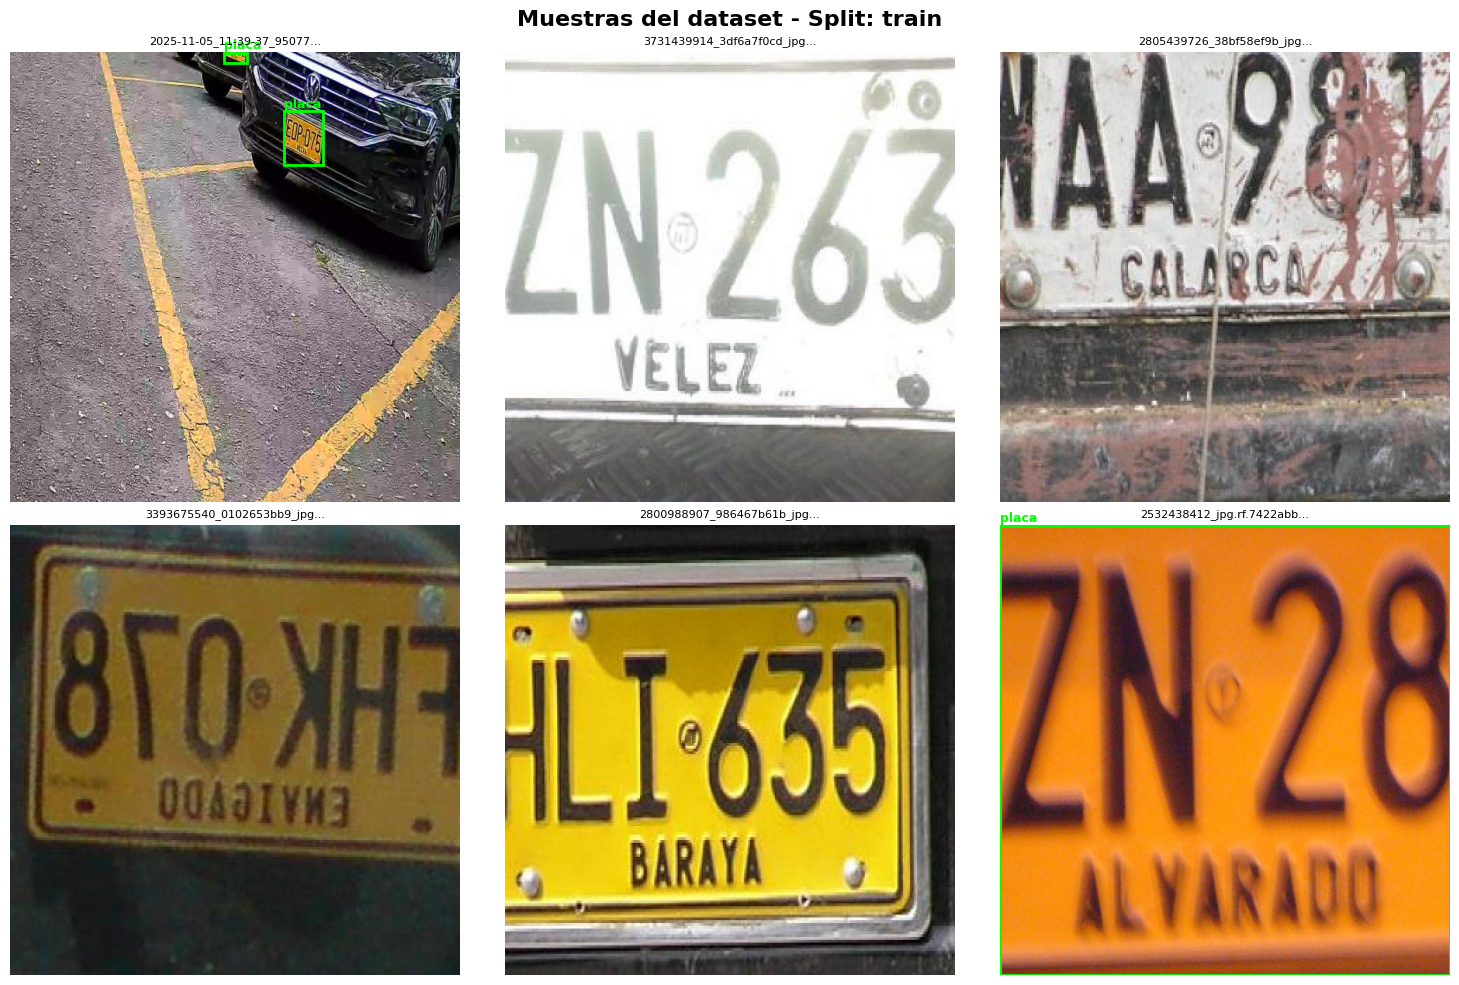

In [ ]:
def mostrar_muestras_dataset(dataset_path, split='train', n=6):
    """Muestra imágenes del dataset con sus bounding boxes."""
    img_dir = os.path.join(dataset_path, split, 'images')
    lbl_dir = os.path.join(dataset_path, split, 'labels')
    imagenes = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
    imagenes = imagenes[:n]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Muestras del dataset - Split: {split}', fontsize=16, fontweight='bold')

    for idx, (ax, img_file) in enumerate(zip(axes.flatten(), imagenes)):
        img_path = os.path.join(img_dir, img_file)
        lbl_path = os.path.join(lbl_dir, img_file.replace('.jpg', '.txt').replace('.png', '.txt').replace('.jpeg', '.txt'))

        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

        # Dibujar bounding boxes si existe el archivo de etiquetas
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls, xc, yc, bw, bh = map(float, parts)
                        x1 = (xc - bw/2) * w
                        y1 = (yc - bh/2) * h
                        rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                                  linewidth=2, edgecolor='lime', facecolor='none')
                        ax.add_patch(rect)
                        ax.text(x1, y1-5, 'placa', color='lime', fontsize=9, fontweight='bold')

        ax.set_title(f'{img_file[:25]}...', fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

mostrar_muestras_dataset(dataset_path, split='train')

---
## 🧠 Paso 6: Carga del Modelo YOLO11

### ¿Qué es YOLO11?

**YOLO11** (You Only Look Once, versión 11) es la versión más reciente del popular detector de objetos en tiempo real. Sus ventajas son:

- ⚡ **Velocidad**: Detecta objetos en milisegundos
- 🎯 **Precisión**: Estado del arte en detección de objetos
- 🪶 **Ligereza**: Varios tamaños de modelo disponibles

### Variantes disponibles de YOLO11

| Modelo | Parámetros | Velocidad | Precisión |
|--------|-----------|-----------|----------|
| yolo11n | 2.6M | ⚡⚡⚡⚡ | ⭐⭐ |
| yolo11s | 9.4M | ⚡⚡⚡ | ⭐⭐⭐ |
| yolo11m | 20.1M | ⚡⚡ | ⭐⭐⭐⭐ |
| **yolo11l** | **25.3M** | **⚡** | **⭐⭐⭐⭐⭐** |

Usamos `yolo11l.pt` (large) para máxima precisión en la detección de placas.

In [ ]:
from ultralytics import YOLO

# Cargar YOLO11 Large preentrenado en COCO dataset
# El modelo se descarga automáticamente la primera vez
model = YOLO("yolo11l.pt")

print("✅ Modelo YOLO11-Large cargado correctamente")
print("\n📋 Información del modelo:")
model.info()

✅ Modelo YOLO11-Large cargado correctamente

📋 Información del modelo:
YOLO11l summary: 357 layers, 25,372,160 parameters, 0 gradients, 87.6 GFLOPs


(357, 25372160, 0, 87.6134912)

---
## ⚙️ Paso 7: Configuración de Ultralytics

Configuramos el directorio donde Ultralytics buscará el dataset. Esto es necesario para que la ruta en `data.yaml` funcione correctamente dentro de Google Colab.

**Nota técnica:** Ultralytics usa una variable de configuración `datasets_dir` que define la raíz de los datasets. Al apuntarla al directorio padre de nuestro dataset, aseguramos que las rutas relativas en `data.yaml` sean correctas.

In [ ]:
from ultralytics import settings

# Configurar el directorio del dataset
settings.update({'datasets_dir': dataset_path})

print(f"✅ Directorio del dataset configurado: {dataset_path}")
print(f"📄 Archivo YAML: {yaml_path}")

✅ Directorio del dataset configurado: /content/placa-de-carro-4
📄 Archivo YAML: /content/placa-de-carro-4/data.yaml


---
## 🏋️ Paso 8: Entrenamiento del Modelo

### ¿Qué es Transfer Learning?

En lugar de entrenar desde cero, usamos **Transfer Learning**: tomamos un modelo ya preentrenado en millones de imágenes (COCO dataset) y lo **fine-tuneamos** con nuestras imágenes de placas colombianas.

Esto nos da:
- ✅ Menos datos necesarios para entrenar
- ✅ Convergencia más rápida
- ✅ Mejor rendimiento final

### Parámetros de entrenamiento

| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| `epochs` | 50 | Número de veces que el modelo ve todo el dataset |
| `imgsz` | 640 | Tamaño de imagen de entrada (640×640 píxeles) |
| `batch` | 16 | Imágenes procesadas simultáneamente (ajustar según VRAM) |
| `patience` | 10 | Parar si no mejora en 10 épocas (early stopping) |
| `device` | 0 | Usar GPU 0 (CUDA) |

> ⏱️ El entrenamiento puede tomar entre 15-40 minutos dependiendo del tamaño del dataset y la GPU de Colab.

In [ ]:
# Entrenamiento del modelo con fine-tuning
results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=10,          # Early stopping: para si no mejora en 10 épocas
    name="detector_placas",
    project="/content/proyecto_placas",
    device=0,             # Usar GPU
    verbose=True
)

print("\n✅ Entrenamiento completado")
print(f"📁 Resultados guardados en: /content/proyecto_placas/detector_placas")

Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/placa-de-carro-4/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detector_placas, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

---
## 📊 Paso 9: Análisis de Métricas de Entrenamiento

Durante el entrenamiento, YOLO11 guarda métricas clave en un archivo `results.csv`. Analizamos:

- **`train/cls_loss`**: Pérdida de clasificación (qué tan bien identifica la clase `placa`)
- **`train/box_loss`**: Pérdida de localización (qué tan preciso es el bounding box)
- **`metrics/mAP50(B)`**: Mean Average Precision con IoU=0.5 (métrica principal)
- **`metrics/precision(B)`**: Precisión — de las detecciones, cuántas son correctas
- **`metrics/recall(B)`**: Recall — de las placas reales, cuántas detectó

**Un buen modelo** debería tener mAP50 > 0.85 y ambas pérdidas decreciendo.

📊 Últimas 5 épocas:
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0   lr/pg1   lr/pg2
    37 1464.25         0.74636         0.60469         1.14763               0.95813            0.95413           0.96821              0.73749       0.81848       0.55092       1.14963 0.000574 0.000574 0.000574
    38 1499.49         0.78899         0.62019         1.15792               0.96452            0.96330           0.98316              0.75491       0.75155       0.52433       1.08612 0.000535 0.000535 0.000535
    39 1535.40         0.74652         0.59540         1.15282               0.97247            0.97240           0.98246              0.74082       0.82909       0.49467       1.18675 0.000495 0.000495 0.000495
    40 1575.21         0.75745         0.59822         1.13536               0.97280            0.94495           0.98836           

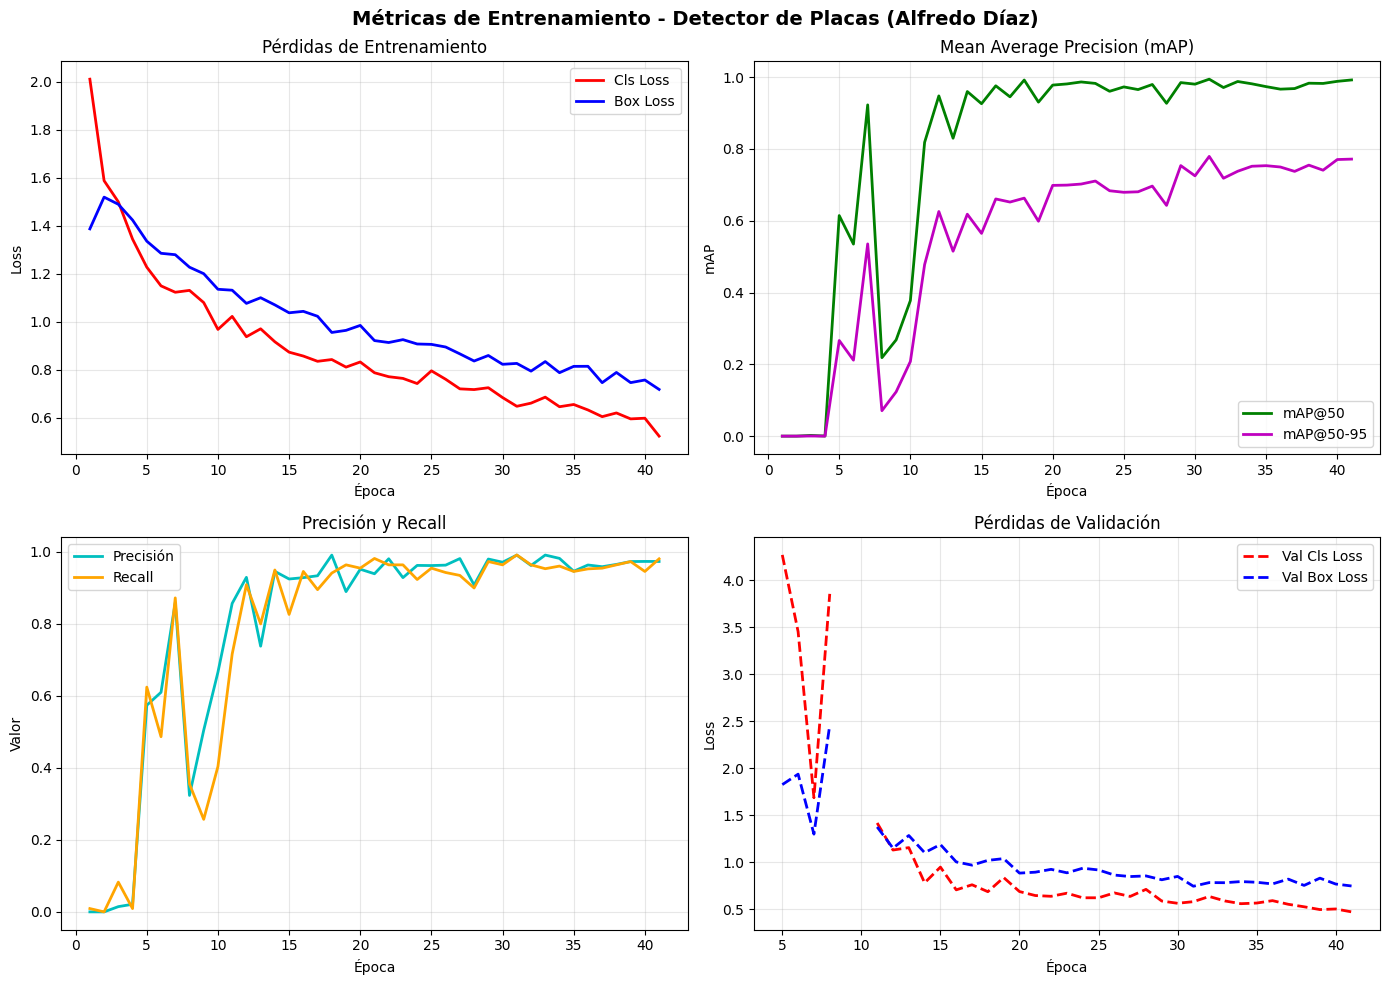


🏆 Mejor época: 31
   mAP@50:     0.9944
   Precisión:  0.9903
   Recall:     0.9908


In [ ]:
# Cargar métricas de entrenamiento
results_path = "/content/proyecto_placas/detector_placas/results.csv"
df_metrics = pd.read_csv(results_path)
df_metrics.columns = df_metrics.columns.str.strip()  # Limpiar espacios en nombres

print("📊 Últimas 5 épocas:")
print(df_metrics.tail(5).to_string(index=False))

# Graficar métricas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Métricas de Entrenamiento - Detector de Placas (Alfredo Díaz)',
             fontsize=14, fontweight='bold')

# Pérdidas de entrenamiento
axes[0, 0].plot(df_metrics['epoch'], df_metrics['train/cls_loss'], 'r-', label='Cls Loss', linewidth=2)
axes[0, 0].plot(df_metrics['epoch'], df_metrics['train/box_loss'], 'b-', label='Box Loss', linewidth=2)
axes[0, 0].set_title('Pérdidas de Entrenamiento')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# mAP
axes[0, 1].plot(df_metrics['epoch'], df_metrics['metrics/mAP50(B)'], 'g-', label='mAP@50', linewidth=2)
axes[0, 1].plot(df_metrics['epoch'], df_metrics['metrics/mAP50-95(B)'], 'm-', label='mAP@50-95', linewidth=2)
axes[0, 1].set_title('Mean Average Precision (mAP)')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('mAP')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precisión y Recall
axes[1, 0].plot(df_metrics['epoch'], df_metrics['metrics/precision(B)'], 'c-', label='Precisión', linewidth=2)
axes[1, 0].plot(df_metrics['epoch'], df_metrics['metrics/recall(B)'], 'orange', label='Recall', linewidth=2)
axes[1, 0].set_title('Precisión y Recall')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Valor')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Pérdida de validación
axes[1, 1].plot(df_metrics['epoch'], df_metrics['val/cls_loss'], 'r--', label='Val Cls Loss', linewidth=2)
axes[1, 1].plot(df_metrics['epoch'], df_metrics['val/box_loss'], 'b--', label='Val Box Loss', linewidth=2)
axes[1, 1].set_title('Pérdidas de Validación')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Loss')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/content/metricas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

# Resumen final
mejor_epoch = df_metrics['metrics/mAP50(B)'].idxmax()
print(f"\n🏆 Mejor época: {df_metrics.loc[mejor_epoch, 'epoch']:.0f}")
print(f"   mAP@50:     {df_metrics.loc[mejor_epoch, 'metrics/mAP50(B)']:.4f}")
print(f"   Precisión:  {df_metrics.loc[mejor_epoch, 'metrics/precision(B)']:.4f}")
print(f"   Recall:     {df_metrics.loc[mejor_epoch, 'metrics/recall(B)']:.4f}")

---
## ✅ Paso 10: Evaluación del Modelo en el Conjunto de Prueba

Evaluamos el modelo final con el conjunto de **test** (imágenes que el modelo nunca vio durante el entrenamiento). Esto nos da una estimación realista del rendimiento en el mundo real.

Métricas que reporta YOLO:
- **mAP50**: Precisión media con umbral IoU de 0.5 (estándar más usado)
- **mAP50-95**: Más estricto, promedio de IoU de 0.5 a 0.95
- **F1-Score**: Balance entre precisión y recall

In [ ]:
# Cargar el mejor modelo entrenado (best.pt)
ruta_modelo = "/content/proyecto_placas/detector_placas/weights/best.pt"
modelo_entrenado = YOLO(ruta_modelo)

print(f"✅ Modelo cargado desde: {ruta_modelo}")

# Evaluar en el conjunto de validación
print("\n🔍 Evaluando en conjunto de validación...")
eval_results = modelo_entrenado.val(
    data=yaml_path,
    split='val'
)

print("\n📊 Resultados de evaluación:")
print(f"   mAP@50:      {eval_results.box.map50:.4f}")
print(f"   mAP@50-95:   {eval_results.box.map:.4f}")
print(f"   Precisión:   {eval_results.box.mp:.4f}")
print(f"   Recall:      {eval_results.box.mr:.4f}")

✅ Modelo cargado desde: /content/proyecto_placas/detector_placas/weights/best.pt

🔍 Evaluando en conjunto de validación...
Ultralytics 8.4.39 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l summary (fused): 191 layers, 25,280,083 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1283.8±574.9 MB/s, size: 39.1 KB)
val: Scanning /content/placa-de-carro-4/valid/labels.cache... 110 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 110/110 35.5Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 94, len(boxes) = 109. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.4it/s 4.9s
                   all        110        109       0.99      0.991      0.994      0.779

---
## 🔬 Paso 11: Detección con OpenCV

### ¿Por qué OpenCV?

**OpenCV** (Open Computer Vision) nos permite:
1. **Recortar** la región de la placa detectada por YOLO
2. **Preprocesar** la imagen para mejorar el OCR (escala de grises, umbralización, etc.)
3. **Visualizar** el resultado con anotaciones dibujadas en la imagen

### Flujo de detección

```
Imagen original
     ↓
YOLO11 → Coordenadas del bounding box (x1, y1, x2, y2)
     ↓
OpenCV recorta la región → Imagen de la placa
     ↓
Preprocesamiento → Escala de grises → Mejora de contraste
     ↓
EasyOCR → Texto de la placa
```

En la siguiente celda definimos la función principal del sistema.

In [ ]:
# Inicializar EasyOCR con soporte para español e inglés
# gpu=True para usar aceleración CUDA si está disponible
print("⏳ Inicializando EasyOCR (puede tardar unos segundos)...")
reader = easyocr.Reader(['es', 'en'], gpu=True)
print("✅ EasyOCR inicializado")


def preprocesar_placa(imagen_placa):
    """
    Preprocesa la región de la placa para mejorar el OCR.

    Pasos:
    1. Convertir a escala de grises
    2. Aumentar tamaño (upscaling) para mejor resolución
    3. Aplicar CLAHE para mejorar el contraste
    4. Reducir ruido con filtro bilateral
    """
    # Convertir BGR (OpenCV) a escala de grises
    gris = cv2.cvtColor(imagen_placa, cv2.COLOR_BGR2GRAY)

    # Aumentar resolución 2x para mejor lectura OCR
    alto, ancho = gris.shape
    gris = cv2.resize(gris, (ancho * 2, alto * 2), interpolation=cv2.INTER_CUBIC)

    # CLAHE: mejora contraste de forma adaptativa
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gris = clahe.apply(gris)

    # Filtro bilateral: reduce ruido preservando bordes
    gris = cv2.bilateralFilter(gris, 11, 17, 17)

    return gris


def extraer_ciudad_placa(texto_placa):
    """
    Interpreta el texto OCR para extraer el número y ciudad de la placa.

    Formato placa colombiana: ABC-123 o ABC 123
    - Primeras 3 letras: identificador del departamento/ciudad
    - Últimos 3 números: código numérico

    Tabla parcial de departamentos colombianos por prefijos:
    """
    # Diccionario de prefijos de placas colombianas por ciudad/departamento
    prefijos_ciudades = {
        # Bogotá D.C.
        'AAA': 'Bogotá', 'BAA': 'Bogotá', 'CAA': 'Bogotá', 'DAA': 'Bogotá',
        'EAA': 'Bogotá', 'FAA': 'Bogotá', 'GAA': 'Bogotá', 'HAA': 'Bogotá',
        # Antioquia (Medellín)
        'HIM': 'Medellín', 'MEP': 'Medellín', 'OCA': 'Medellín',
        # Valle del Cauca (Cali)
        'BXR': 'Cali', 'CXR': 'Cali', 'DXR': 'Cali',
        # Santander (Bucaramanga)
        'OBR': 'Bucaramanga', 'OBS': 'Bucaramanga', 'OBT': 'Bucaramanga',
        'OBU': 'Bucaramanga', 'OBV': 'Bucaramanga',
        # Atlántico (Barranquilla)
        'BCH': 'Barranquilla', 'BCJ': 'Barranquilla',
        # Cundinamarca
        'OHG': 'Cundinamarca', 'OHH': 'Cundinamarca',
    }

    import re
    # Limpiar el texto: remover caracteres no alfanuméricos excepto guion
    texto_limpio = re.sub(r'[^A-Za-z0-9-]', '', texto_placa).upper()

    # Buscar patrón de placa colombiana: 3 letras + 3 números
    patron = re.search(r'([A-Z]{3})[\-]?([0-9]{3})', texto_limpio)

    if patron:
        letras = patron.group(1)
        numeros = patron.group(2)
        placa_formateada = f"{letras}-{numeros}"

        # Buscar ciudad por prefijo exacto o los 2 primeros caracteres
        ciudad = prefijos_ciudades.get(letras, None)
        if not ciudad:
            # Buscar por los primeros 2 caracteres si no hay coincidencia exacta
            for prefijo, c in prefijos_ciudades.items():
                if letras[:2] == prefijo[:2]:
                    ciudad = c
                    break
        ciudad = ciudad or "Desconocida (ver tabla RUNT)"

        return placa_formateada, letras, numeros, ciudad

    return texto_limpio, "", "", "No identificada"


print("✅ Funciones de procesamiento definidas")

⏳ Inicializando EasyOCR (puede tardar unos segundos)...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete✅ EasyOCR inicializado
✅ Funciones de procesamiento definidas


---
## 📖 Paso 12: Sistema Completo de Detección y Lectura de Placa

Aquí integramos todo el pipeline:
1. YOLO11 detecta la placa en la imagen
2. OpenCV recorta la región detectada
3. Se preprocesa la imagen para mejor OCR
4. EasyOCR lee el texto de la placa
5. Se interpreta el texto para extraer el número y ciudad

La función `detectar_y_leer_placa()` encapsula todo este flujo.

In [ ]:
def detectar_y_leer_placa(ruta_imagen, modelo, reader_ocr, confianza_min=0.3, mostrar=True):
    """
    Pipeline completo: Detecta la placa con YOLO11, recorta con OpenCV,
    lee con EasyOCR y extrae ciudad.

    Args:
        ruta_imagen: Ruta de la imagen a procesar
        modelo: Modelo YOLO11 entrenado
        reader_ocr: Instancia de EasyOCR
        confianza_min: Confianza mínima para aceptar detección (0-1)
        mostrar: Si True, muestra visualización

    Returns:
        dict con resultados o None si no se detectó placa
    """
    # ── 1. Cargar imagen con OpenCV ──────────────────────────────
    imagen_bgr = cv2.imread(ruta_imagen)
    if imagen_bgr is None:
        print(f"❌ No se pudo cargar la imagen: {ruta_imagen}")
        return None
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    alto, ancho = imagen_bgr.shape[:2]

    # ── 2. Detección con YOLO11 ──────────────────────────────────
    resultados_yolo = modelo.predict(
        source=ruta_imagen,
        conf=confianza_min,
        verbose=False
    )

    if len(resultados_yolo) == 0 or len(resultados_yolo[0].boxes) == 0:
        print("⚠️  No se detectaron placas en la imagen.")
        return None

    # Tomar la detección con mayor confianza
    boxes = resultados_yolo[0].boxes
    mejor_idx = boxes.conf.argmax().item()

    # Coordenadas del bounding box (x1, y1, x2, y2) en píxeles
    x1, y1, x2, y2 = map(int, boxes.xyxy[mejor_idx].tolist())
    confianza = float(boxes.conf[mejor_idx])

    # ── 3. Recorte con OpenCV ────────────────────────────────────
    # Añadir un pequeño margen al recorte para no perder bordes de letras
    margen = 5
    x1m = max(0, x1 - margen)
    y1m = max(0, y1 - margen)
    x2m = min(ancho, x2 + margen)
    y2m = min(alto, y2 + margen)

    recorte_bgr = imagen_bgr[y1m:y2m, x1m:x2m]
    recorte_rgb = imagen_rgb[y1m:y2m, x1m:x2m]

    # ── 4. Preprocesamiento para OCR ─────────────────────────────
    placa_procesada = preprocesar_placa(recorte_bgr)

    # ── 5. OCR con EasyOCR ───────────────────────────────────────
    # EasyOCR acepta imágenes numpy directamente
    ocr_resultados = reader_ocr.readtext(
        placa_procesada,
        detail=1,          # Retornar coordenadas + texto + confianza
        paragraph=False,   # No agrupar en párrafos
        allowlist='ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-'  # Solo chars de placa
    )

    # Combinar todos los textos detectados por OCR
    texto_raw = ' '.join([res[1] for res in ocr_resultados])
    conf_ocr = np.mean([res[2] for res in ocr_resultados]) if ocr_resultados else 0.0

    # ── 6. Extracción de información de la placa ─────────────────
    placa_fmt, letras, numeros, ciudad = extraer_ciudad_placa(texto_raw)

    # ── 7. Visualización ─────────────────────────────────────────
    if mostrar:
        fig = plt.figure(figsize=(16, 6))
        fig.suptitle(f'Resultado: {placa_fmt} — {ciudad}',
                     fontsize=16, fontweight='bold', color='darkblue')

        # Imagen original con bounding box
        ax1 = fig.add_subplot(1, 3, 1)
        img_anotada = imagen_rgb.copy()
        cv2.rectangle(img_anotada, (x1, y1), (x2, y2), (0, 255, 0), 3)
        etiqueta = f"{placa_fmt} ({confianza:.0%})"
        cv2.putText(img_anotada, etiqueta, (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        ax1.imshow(img_anotada)
        ax1.set_title(f'Detección YOLO11\nConfianza: {confianza:.1%}', fontsize=11)
        ax1.axis('off')

        # Recorte original de la placa
        ax2 = fig.add_subplot(1, 3, 2)
        ax2.imshow(recorte_rgb)
        ax2.set_title('Recorte OpenCV\n(Región de la placa)', fontsize=11)
        ax2.axis('off')

        # Imagen preprocesada para OCR
        ax3 = fig.add_subplot(1, 3, 3)
        ax3.imshow(placa_procesada, cmap='gray')
        ax3.set_title(f'Preprocesada (OCR)\nTexto: "{texto_raw}"', fontsize=11)
        ax3.axis('off')

        plt.tight_layout()
        plt.show()

        # Resultados textuales
        print("\n" + "="*50)
        print("🚗 RESULTADO DEL ANÁLISIS")
        print("="*50)
        print(f"  🔍 Confianza YOLO11:   {confianza:.1%}")
        print(f"  📝 Texto OCR crudo:    '{texto_raw}'")
        print(f"  🪪  Placa detectada:   {placa_fmt}")
        print(f"  🔤 Letras:             {letras}")
        print(f"  🔢 Números:            {numeros}")
        print(f"  📍 Ciudad/Depto:       {ciudad}")
        print(f"  🤖 Confianza OCR:      {conf_ocr:.1%}")
        print("="*50)

    return {
        'placa': placa_fmt,
        'letras': letras,
        'numeros': numeros,
        'ciudad': ciudad,
        'texto_raw': texto_raw,
        'confianza_yolo': confianza,
        'confianza_ocr': conf_ocr,
        'bbox': (x1, y1, x2, y2)
    }

print("✅ Función detectar_y_leer_placa() lista")

✅ Función detectar_y_leer_placa() lista


---
## 🧪 Paso 13: Prueba con Imágenes del Conjunto de Test

Ahora probamos el sistema completo con las imágenes de prueba del dataset. Esto nos permite ver cómo funciona el pipeline end-to-end con imágenes reales que el modelo nunca vio durante el entrenamiento.

In [ ]:
# Obtener imágenes del conjunto de test
test_dir = os.path.join(dataset_path, 'test', 'images')

if os.path.exists(test_dir):
    imagenes_test = [
        os.path.join(test_dir, f)
        for f in os.listdir(test_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ][:5]  # Procesar las primeras 5 imágenes

    print(f"📁 Encontradas {len(imagenes_test)} imágenes de prueba")
    print("-" * 50)

    resultados_finales = []

    for i, ruta in enumerate(imagenes_test):
        print(f"\n🔎 Procesando imagen {i+1}/{len(imagenes_test)}: {os.path.basename(ruta)}")
        resultado = detectar_y_leer_placa(ruta, modelo_entrenado, reader, mostrar=True)
        if resultado:
            resultado['archivo'] = os.path.basename(ruta)
            resultados_finales.append(resultado)
else:
    print("⚠️  No se encontró directorio de test. Usando validación.")
    test_dir = os.path.join(dataset_path, 'valid', 'images')
    imagenes_test = [
        os.path.join(test_dir, f)
        for f in os.listdir(test_dir)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ][:5]

Output hidden; open in https://colab.research.google.com to view.

---
## 📋 Paso 14: Tabla de Resultados

Mostramos todos los resultados en una tabla resumen para evaluar el rendimiento del sistema de forma rápida.

In [ ]:
if resultados_finales:
    df_resultados = pd.DataFrame(resultados_finales)
    cols_mostrar = ['archivo', 'placa', 'letras', 'numeros', 'ciudad', 'confianza_yolo', 'confianza_ocr']
    cols_disponibles = [c for c in cols_mostrar if c in df_resultados.columns]

    print("\n📊 Resumen de resultados:")
    print(df_resultados[cols_disponibles].to_string(index=False))

    print(f"\n✅ Placas detectadas exitosamente: {len(resultados_finales)}/{len(imagenes_test)}")
    print(f"🎯 Confianza promedio YOLO: {df_resultados['confianza_yolo'].mean():.1%}")
    if 'confianza_ocr' in df_resultados.columns:
        print(f"🔤 Confianza promedio OCR: {df_resultados['confianza_ocr'].mean():.1%}")
else:
    print("⚠️  No se generaron resultados para mostrar.")


📊 Resumen de resultados:
                                                            archivo   placa letras numeros                       ciudad  confianza_yolo  confianza_ocr
3391663121_b79ea0654c_z_jpg.rf.fa409a54f6e9323cfd87c0bb24cb067a.jpg     980                             No identificada        0.877706       0.550014
             2537026231_jpg.rf.f8e9712ecb5c08935a5c78e7487f642f.jpg    1I96                             No identificada        0.900859       0.385125
3809814058_24e823d4a2_w_jpg.rf.135d13d3009a020b8cf917db04d61685.jpg BJY-780    BJY     780 Desconocida (ver tabla RUNT)        0.748432       0.952743
  2506051050_b4e4fd1dd0_jpg.rf.49e5ba71d7b8e170914dabab39dfcbfb.jpg DAK-253    DAK     253                       Bogotá        0.869631       0.998822
  2920180387_272dd573be_jpg.rf.27bb9258ff8b53ac27edefaf6ba7a98c.jpg   7FE24                             No identificada        0.816371       0.219142

✅ Placas detectadas exitosamente: 5/5
🎯 Confianza promedio YOLO: 84

---
## 📷 Paso 15: Probar con tu Propia Imagen

Puedes probar el sistema con cualquier foto de una placa colombiana. Solo sube tu imagen a Google Colab y ejecuta la celda de abajo.

**Cómo subir una imagen:**
1. En el panel izquierdo de Colab, haz clic en el ícono de carpeta 📁
2. Arrastra tu imagen o haz clic en el botón de subida
3. Copia la ruta (por ejemplo: `/content/mi_placa.jpg`)
4. Pégala en la variable `MI_IMAGEN` de la celda siguiente

In [ ]:
MI_IMAGEN = "https://www.shutterstock.com/image-photo/colombia-armenia-jun-25-2024-600w-2664753931.jpg"   # ← Reemplazar con tu ruta
# ─────────────────────────────────────────────────

if os.path.exists(MI_IMAGEN):
    print(f"4F7 Procesando: {MI_IMAGEN}")
    resultado_custom = detectar_y_leer_placa(
        MI_IMAGEN,
        modelo_entrenado,
        reader,
        confianza_min=0.25,  # Umbral más bajo para imágenes difíciles
        mostrar=True
    )
else:
    print(f"⚠️  Imagen no encontrada en: {MI_IMAGEN}")
    print("4A1 Sube tu imagen a Colab y actualiza la variable MI_IMAGEN")

⚠️  Imagen no encontrada en: https://www.shutterstock.com/image-photo/colombia-armenia-jun-25-2024-600w-2664753931.jpg
4A1 Sube tu imagen a Colab y actualiza la variable MI_IMAGEN


In [ ]:
MI_IMAGEN = "https://www.shutterstock.com/image-photo/colombia-armenia-jun-25-2024-600w-2664753931.jpg"   # ← Reemplazar con tu ruta
# ─────────────────────────────────────────────────

if os.path.exists(MI_IMAGEN):
    print(f"4F7 Procesando: {MI_IMAGEN}")
    resultado_custom = detectar_y_leer_placa(
        MI_IMAGEN,
        modelo_entrenado,
        reader,
        confianza_min=0.25,  # Umbral más bajo para imágenes difíciles
        mostrar=True
    )
else:
    print(f"⚠️  Imagen no encontrada en: {MI_IMAGEN}")
    print("4A1 Sube tu imagen a Colab y actualiza la variable MI_IMAGEN")

⚠️  Imagen no encontrada en: https://www.shutterstock.com/image-photo/colombia-armenia-jun-25-2024-600w-2664753931.jpg
4A1 Sube tu imagen a Colab y actualiza la variable MI_IMAGEN


In [ ]:
MI_IMAGEN = "https://www.shutterstock.com/image-photo/colombia-armenia-jun-25-2024-600w-2664753931.jpg"   # ← Reemplazar con tu ruta
# ─────────────────────────────────────────────────

if os.path.exists(MI_IMAGEN):
    print(f"4F7 Procesando: {MI_IMAGEN}")
    resultado_custom = detectar_y_leer_placa(
        MI_IMAGEN,
        modelo_entrenado,
        reader,
        confianza_min=0.25,  # Umbral más bajo para imágenes difíciles
        mostrar=True
    )
else:
    print(f"⚠️  Imagen no encontrada en: {MI_IMAGEN}")
    print("4A1 Sube tu imagen a Colab y actualiza la variable MI_IMAGEN")

⚠️  Imagen no encontrada en: https://www.shutterstock.com/image-photo/colombia-armenia-jun-25-2024-600w-2664753931.jpg
4A1 Sube tu imagen a Colab y actualiza la variable MI_IMAGEN


In [ ]:
import requests
from PIL import Image
from io import BytesIO

image_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/1/1a/Placa_de_autom%C3%B3vil_Colombia.jpg/640px-Placa_de_autom%C3%B3vil_Colombia.jpg"

try:
    response = requests.get(image_url)
    response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)

    # Use PIL to open the image from bytes
    img = Image.open(BytesIO(response.content))
    local_image_path = "/content/downloaded_image.jpg"
    img.save(local_image_path)

    MI_IMAGEN = local_image_path

    print(f"✅ Imagen descargada exitosamente a: {MI_IMAGEN}")

    if os.path.exists(MI_IMAGEN):
        print(f"📷 Procesando: {MI_IMAGEN}")
        resultado_custom = detectar_y_leer_placa(
            MI_IMAGEN,
            modelo_entrenado,
            reader,
            confianza_min=0.25,  # Umbral más bajo para imágenes difíciles
            mostrar=True
        )
    else:
        print(f"⚠️  Imagen no encontrada en: {MI_IMAGEN}")

except requests.exceptions.RequestException as e:
    print(f"❌ Error al descargar la imagen: {e}")
except Exception as e:
    print(f"❌ Error al procesar la imagen: {e}")

---
## 💾 Paso 16: Guardar y Descargar el Modelo Entrenado

Comprimimos todos los resultados del entrenamiento (pesos del modelo, métricas, gráficas) en un archivo ZIP para poder descargarlo y usarlo posteriormente sin necesidad de reentrenar.

El archivo `best.pt` dentro de `weights/` es el más importante: es el modelo final que puedes reutilizar en cualquier proyecto.

In [ ]:
import shutil
from google.colab import files

# Verificar que el modelo existe
ruta_best = "/content/proyecto_placas/detector_placas/weights/best.pt"
if os.path.exists(ruta_best):
    tamano_mb = os.path.getsize(ruta_best) / (1024 * 1024)
    print(f"✅ Modelo encontrado: best.pt ({tamano_mb:.1f} MB)")
else:
    print("⚠️  Modelo no encontrado. ¿Completaste el entrenamiento?")

# Comprimir la carpeta del proyecto
folder_path = "/content/proyecto_placas"
output_zip = "/content/alfredo_placas_v5"

print("\n⏳ Comprimiendo archivos del proyecto...")
shutil.make_archive(output_zip, 'zip', folder_path)
print(f"✅ Archivo ZIP creado: {output_zip}.zip")

# Descargar el ZIP
print("\n⬇️  Iniciando descarga...")
files.download(f"{output_zip}.zip")

---
## 🎓 Resumen del Proyecto

### ¿Qué construimos?

Desarrollamos un sistema completo de **detección y lectura automática de placas vehiculares colombianas** que:

1. ✅ Descarga un dataset etiquetado desde **Roboflow**
2. ✅ Entrena un modelo **YOLO11** para detectar placas (`clase: placa`)
3. ✅ Usa **OpenCV** para recortar y preprocesar la región de la placa
4. ✅ Aplica **EasyOCR** para leer los caracteres de la placa
5. ✅ Extrae el **número de placa** y la **ciudad/departamento**

### Posibles mejoras

- 🔄 **Más datos**: Agregar más imágenes de placas con diferentes condiciones de luz
- 🎯 **OCR específico**: Entrenar un modelo OCR exclusivo para placas colombianas
- 🌙 **Preprocesamiento nocturno**: Técnicas específicas para imágenes con poca luz
- 📱 **Deployment**: Exportar el modelo a formato ONNX o TFLite para apps móviles
- 🗃️ **Base de datos RUNT**: Integrar con la base de datos oficial para validar placas

---
**Adaptación realizada por Alfredo Díaz** | Dataset: Roboflow - cicatriz/placa-de-carro-sxy3a v4